In [1]:
# ============================================================
#  环境配置
#  - Colab 用户：取消注释下方 Colab 区块
#  - 本地 Jupyter 用户：直接运行 Local 区块
# ============================================================

# ── Colab 环境（取消注释后运行） ──
!pip install torch torchvision matplotlib numpy -U -q

# ── 本地 Jupyter 环境 ──
# import subprocess, sys
# def _install(pkg):
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# _install("torch==2.5.1")
# _install("torchvision==0.20.1")
# _install("matplotlib==3.9.4")
# _install("numpy==1.26.4")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 53.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.


# Vision Transformer (ViT) 从零到一：源代码实现 vs 简洁实现

基于论文 *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale* (Dosovitskiy et al., 2020)，
用 **CIFAR-10 图像分类** 任务演示 ViT 的核心架构。

本 Notebook 包含两种实现，使用 **相同的超参数和数据**：

| | 实现 A — 源代码实现 | 实现 B — 简洁实现 |
|---|---|---|
| 核心思路 | 逐组件手写 Patch Embedding / MSA / Encoder Block | 使用 `nn.TransformerEncoder` + `nn.Conv2d` |
| 代码量 | ~80 行 | ~30 行 |
| 适合场景 | 深入理解 ViT 原理、面试准备 | 快速原型、工程落地 |
| 推理方式 | 图像 → Patch → Transformer → [CLS] → 类别 | 同左 |

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. 数据准备

使用 CIFAR-10 数据集的子集（5000 训练 / 1000 测试），图像大小 $32 \times 32 \times 3$。
训练集添加随机翻转和裁剪增强，使用标准 CIFAR-10 归一化参数。

In [3]:
# ── 超参数（两种实现共用，集中管理） ──
IMG_SIZE     = 32       # CIFAR-10 图像尺寸
IN_CHANNELS  = 3        # RGB 通道数
PATCH_SIZE   = 4        # Patch 大小 (4×4)
NUM_PATCHES  = (IMG_SIZE // PATCH_SIZE) ** 2  # 64 个 Patch
PATCH_DIM    = PATCH_SIZE ** 2 * IN_CHANNELS  # 48 (展平后的 Patch 维度)
D_MODEL      = 64       # Embedding 维度（论文 768，此处缩小适配 CPU）
NUM_HEADS    = 4        # 注意力头数
HEAD_DIM     = D_MODEL // NUM_HEADS  # 16
NUM_LAYERS   = 4        # Encoder 层数（论文 12）
D_FF         = 128      # FFN 隐藏维度（论文 3072）
DROPOUT      = 0.1
NUM_CLASSES  = 10       # CIFAR-10 类别数
LR           = 3e-4     # 学习率
NUM_EPOCHS   = 50       # CPU 友好
BATCH_SIZE   = 64
NUM_TRAIN    = 5000     # 训练子集大小
NUM_TEST     = 1000     # 测试子集大小

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

In [4]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
full_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
train_set = Subset(full_train, range(NUM_TRAIN))
test_set = Subset(full_test, range(NUM_TEST))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
print(f'训练集: {len(train_set)} 样本, {len(train_loader)} 批次')
print(f'测试集: {len(test_set)} 样本, {len(test_loader)} 批次')

100%|██████████| 170M/170M [00:19<00:00, 8.95MB/s]


训练集: 5000 样本, 78 批次
测试集: 1000 样本, 16 批次


批次形状: torch.Size([64, 3, 32, 32])
标签形状: torch.Size([64])
像素范围: [-1.99, 2.13]


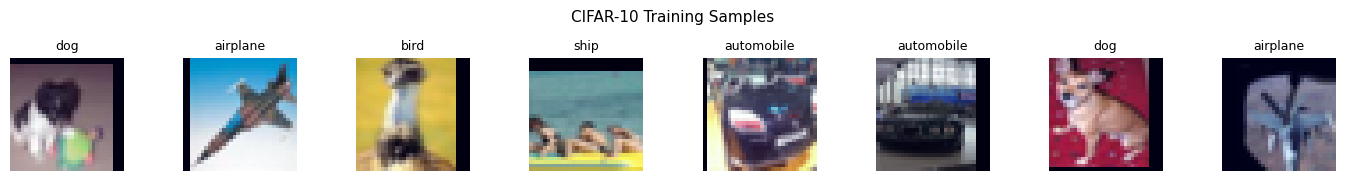

In [5]:
sample_batch, sample_labels = next(iter(train_loader))
print(f'批次形状: {sample_batch.shape}')        # (64, 3, 32, 32)
print(f'标签形状: {sample_labels.shape}')        # (64,)
print(f'像素范围: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]')

fig, axes = plt.subplots(1, 8, figsize=(14, 1.8))
for i, ax in enumerate(axes):
    img = sample_batch[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())  # 反归一化用于显示
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[sample_labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 Training Samples', fontsize=11)
plt.tight_layout()
plt.show()

## 2. 共享组件

训练/评估函数与可视化工具，两种实现共用。

In [6]:
def plot_results(train_losses, test_accs, title='Training'):
    """绘制损失曲线和准确率曲线"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss')
    ax1.grid(True, alpha=0.3)

    ax2.plot(test_accs)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} — Test Accuracy')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [7]:
def train_vit(model, train_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR):
    """
    ViT 训练循环（两种实现共用）
    返回每个 epoch 的训练损失和测试准确率。
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    train_losses, test_accs = [], []

    for epoch in range(num_epochs):
        # ── 训练 ──
        model.train()
        total_loss, n_batch = 0.0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)  # (B,3,32,32), (B,)
            logits = model(imgs)                                # (B, 10)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n_batch += 1

        scheduler.step()
        avg_loss = total_loss / n_batch
        train_losses.append(avg_loss)

        # ── 评估 ──
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = model(imgs).argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        acc = correct / total
        test_accs.append(acc)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1:3d}/{num_epochs}]  Loss: {avg_loss:.4f}  Acc: {acc:.4f}')

    return train_losses, test_accs

### 训练 vs 推理的区别

| 阶段 | 行为 | 说明 |
|------|------|------|
| **训练** | 前向传播 + 反向传播，Dropout 开启 | `model.train()`，计算梯度更新参数 |
| **推理** | 仅前向传播，Dropout 关闭 | `model.eval()` + `torch.no_grad()` |

ViT 的训练和推理流程**基本一致**（不像 Seq2Seq 需要 teacher forcing）：
- 输入图像 → Patch 切分 → Embedding → Transformer Encoder → [CLS] 分类
- 唯一区别是 Dropout 是否激活

---

## 3. 实现 A — 源代码实现

逐组件手写 ViT 的每个部分，包含公式推导和维度注释。

### Patch Embedding

将输入图像切分为不重叠的 Patch，并通过线性投影映射到 $D$ 维空间。

$$\mathbf{x}_p^i \in \mathbb{R}^{P^2 \cdot C} \xrightarrow{\mathbf{E} \in \mathbb{R}^{(P^2 \cdot C) \times D}} \mathbb{R}^D$$

以 CIFAR-10 ($32 \times 32 \times 3$) + Patch 大小 $4 \times 4$ 为例：

- Patch 数量：$(32 / 4)^2 = 64$
- 每个 Patch 展平维度：$4 \times 4 \times 3 = 48$
- 线性投影：$48 \to 64$ (D_MODEL)

切分过程：$(B, 3, 32, 32) \to (B, 64, 48) \to (B, 64, D)$

In [8]:
class PatchEmbeddingScratch(nn.Module):
    """将图像切分为 Patch 并线性投影"""

    def __init__(self, img_size, patch_size, in_channels, d_model):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = patch_size * patch_size * in_channels
        self.proj = nn.Linear(patch_dim, d_model)     # E: (48, 64)

    def forward(self, x):
        # x: (B, 3, 32, 32)
        B, C, H, W = x.shape
        p = self.patch_size
        # 将图像重组为 Patch 序列
        x = x.reshape(B, C, H // p, p, W // p, p)   # (B, 3, 8, 4, 8, 4)
        x = x.permute(0, 2, 4, 3, 5, 1)              # (B, 8, 8, 4, 4, 3)
        x = x.reshape(B, self.num_patches, -1)        # (B, 64, 48)
        x = self.proj(x)                               # (B, 64, D)
        return x

### 多头自注意力（Multi-Head Self-Attention）

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O$$

其中 $\text{head}_i = \text{Attention}(XW_i^Q, XW_i^K, XW_i^V)$，$d_k = D / h$。

- 输入: $(B, N, D)$，$N = 65$（64 个 Patch + 1 个 [CLS]）
- QKV 投影: $(B, N, D) \to (B, h, N, d_k)$
- 注意力矩阵: $(B, h, N, N)$
- 输出: $(B, N, D)$

In [9]:
class MultiHeadAttention(nn.Module):
    """多头自注意力（手写实现）"""

    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = self.head_dim ** -0.5            # 1 / sqrt(d_k)

        self.qkv = nn.Linear(d_model, d_model * 3)   # 合并 Q, K, V 投影
        self.proj = nn.Linear(d_model, d_model)       # 输出投影 W^O
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)
        self._attn_weights = None                     # 保存注意力权重用于可视化

    def forward(self, x):
        # x: (B, N, D)
        B, N, D = x.shape
        h = self.num_heads

        # QKV 投影 + 拆分多头
        qkv = self.qkv(x)                                 # (B, N, 3D)
        qkv = qkv.reshape(B, N, 3, h, self.head_dim)      # (B, N, 3, h, d_k)
        qkv = qkv.permute(2, 0, 3, 1, 4)                  # (3, B, h, N, d_k)
        q, k, v = qkv.unbind(0)                            # 各 (B, h, N, d_k)

        # Scaled Dot-Product Attention
        attn = (q @ k.transpose(-2, -1)) * self.scale      # (B, h, N, N)
        attn = attn.softmax(dim=-1)
        self._attn_weights = attn.detach()
        attn = self.attn_drop(attn)

        # 加权求和 + 合并多头
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)  # (B, N, D)
        out = self.proj_drop(self.proj(out))                # (B, N, D)
        return out

### Transformer Encoder Block（Pre-LN）

ViT 使用 **Pre-LN**（LayerNorm 在子层之前），区别于原始 Transformer 的 Post-LN：

$$\mathbf{z}'_\ell = \text{MSA}(\text{LN}(\mathbf{z}_{\ell-1})) + \mathbf{z}_{\ell-1}$$

$$\mathbf{z}_\ell = \text{MLP}(\text{LN}(\mathbf{z}'_\ell)) + \mathbf{z}'_\ell$$

其中 MLP 包含两层全连接 + GELU 激活：

$$\text{MLP}(x) = \text{GELU}(x W_1 + b_1) W_2 + b_2$$

- **Pre-LN** 的优势：训练更稳定，无需 warmup，梯度更平滑
- **GELU** 而非 ReLU：更平滑的激活函数，在 Transformer 中效果更好

In [10]:
class TransformerBlock(nn.Module):
    """Transformer Encoder Block（Pre-LN 变体）"""

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_ff),        # D -> D_FF
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),         # D_FF -> D
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (B, N, D)
        # Pre-LN: LN → MSA → Add
        x = self.attn(self.norm1(x)) + x     # (B, N, D)
        # Pre-LN: LN → MLP → Add
        x = self.mlp(self.norm2(x)) + x      # (B, N, D)
        return x

### 完整 ViT 模型

组装所有组件：Patch Embedding → [CLS] Token + Position Embedding → $L$ 层 Transformer Block → LayerNorm → 分类头

$$\mathbf{z}_0 = [\mathbf{x}_{\text{class}};\, \mathbf{x}_p^1 \mathbf{E};\, \cdots;\, \mathbf{x}_p^N \mathbf{E}] + \mathbf{E}_{\text{pos}}, \quad \mathbf{E}_{\text{pos}} \in \mathbb{R}^{(N+1) \times D}$$

$$\mathbf{y} = \text{LN}(\mathbf{z}_L^0) \quad \text{(取 [CLS] Token 的输出)}$$

$$\hat{y} = \text{Linear}(\mathbf{y}) \quad \text{(分类头)}$$

In [11]:
class ViTScratch(nn.Module):
    """Vision Transformer 源代码实现"""

    def __init__(self, img_size, patch_size, in_channels, d_model,
                 num_heads, num_layers, d_ff, num_classes, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbeddingScratch(img_size, patch_size, in_channels, d_model)
        num_patches = self.patch_embed.num_patches

        # 可学习的 [CLS] Token 和位置编码
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))
        self.pos_drop = nn.Dropout(dropout)

        # L 层 Transformer Encoder
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)               # 最终 LayerNorm
        self.head = nn.Linear(d_model, num_classes)      # 分类头

        # 初始化
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, 3, 32, 32)
        B = x.shape[0]
        x = self.patch_embed(x)                          # (B, 64, D)

        cls = self.cls_token.expand(B, -1, -1)           # (B, 1, D)
        x = torch.cat([cls, x], dim=1)                   # (B, 65, D)
        x = self.pos_drop(x + self.pos_embed)            # (B, 65, D)

        for block in self.blocks:
            x = block(x)                                  # (B, 65, D)

        cls_out = self.norm(x[:, 0])                     # (B, D) — 取 [CLS]
        logits = self.head(cls_out)                       # (B, num_classes)
        return logits

### 训练实现 A

In [12]:
model_a = ViTScratch(
    IMG_SIZE, PATCH_SIZE, IN_CHANNELS, D_MODEL,
    NUM_HEADS, NUM_LAYERS, D_FF, NUM_CLASSES, DROPOUT
).to(device)

total_params = sum(p.numel() for p in model_a.parameters())
print(f'ViT (源代码实现) 参数量: {total_params:,}')

losses_a, accs_a = train_vit(model_a, train_loader, test_loader)

ViT (源代码实现) 参数量: 142,026
Epoch [ 10/50]  Loss: 1.7070  Acc: 0.3780
Epoch [ 20/50]  Loss: 1.5253  Acc: 0.4600
Epoch [ 30/50]  Loss: 1.3842  Acc: 0.5010
Epoch [ 40/50]  Loss: 1.2947  Acc: 0.5030
Epoch [ 50/50]  Loss: 1.2798  Acc: 0.5080


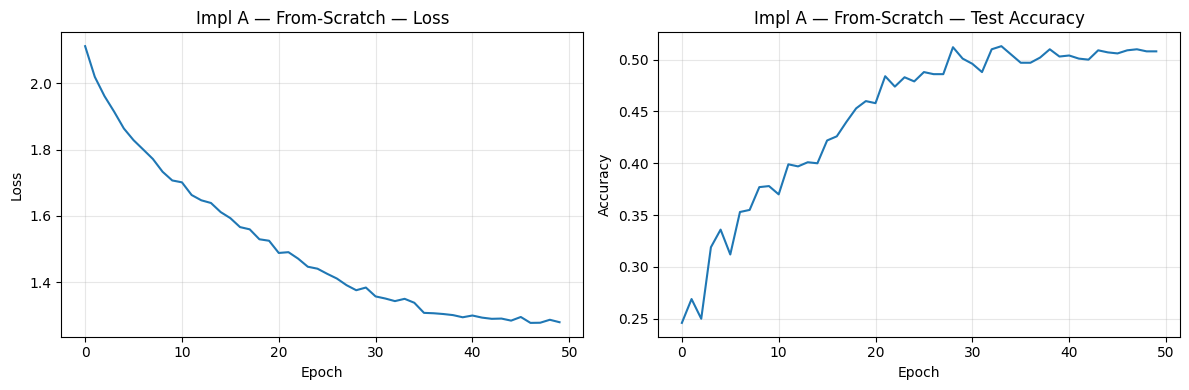

最终测试准确率: 0.5080


In [13]:
plot_results(losses_a, accs_a, title='Impl A — From-Scratch')
print(f'最终测试准确率: {accs_a[-1]:.4f}')

---

## 4. 实现 B — 简洁实现

使用 PyTorch 内置模块简化实现：

| 源代码实现 | 简洁实现 |
|---|---|
| `PatchEmbeddingScratch` (reshape + Linear) | `nn.Conv2d(kernel=stride=patch_size)` |
| `MultiHeadAttention` (手写 QKV) | `nn.TransformerEncoderLayer` 内置 |
| `TransformerBlock` (手写 Pre-LN) | `nn.TransformerEncoderLayer(norm_first=True)` |
| 4 × `TransformerBlock` | `nn.TransformerEncoder(layer, 4)` |

**Patch Embedding 用 Conv2d**：卷积核大小和步幅均等于 Patch 大小，等价于将每个 Patch 线性投影到 $D$ 维空间（无重叠）。

In [14]:
class ViTConcise(nn.Module):
    """Vision Transformer 简洁实现"""

    def __init__(self, img_size, patch_size, in_channels, d_model,
                 num_heads, num_layers, d_ff, num_classes, dropout=0.1):
        super().__init__()
        num_patches = (img_size // patch_size) ** 2

        # Conv2d 实现 Patch Embedding（kernel=stride=patch_size）
        self.patch_embed = nn.Conv2d(
            in_channels, d_model,
            kernel_size=patch_size, stride=patch_size
        )
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))
        self.pos_drop = nn.Dropout(dropout)

        # nn.TransformerEncoder 封装 L 层
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=d_ff,
            dropout=dropout, activation='gelu', batch_first=True,
            norm_first=True    # Pre-LN（ViT 风格）
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        # x: (B, 3, 32, 32)
        B = x.shape[0]
        x = self.patch_embed(x)                          # (B, D, 8, 8)
        x = x.flatten(2).transpose(1, 2)                 # (B, 64, D)

        cls = self.cls_token.expand(B, -1, -1)           # (B, 1, D)
        x = torch.cat([cls, x], dim=1)                   # (B, 65, D)
        x = self.pos_drop(x + self.pos_embed)            # (B, 65, D)

        x = self.encoder(x)                              # (B, 65, D)

        cls_out = self.norm(x[:, 0])                     # (B, D)
        logits = self.head(cls_out)                       # (B, num_classes)
        return logits

In [15]:
model_b = ViTConcise(
    IMG_SIZE, PATCH_SIZE, IN_CHANNELS, D_MODEL,
    NUM_HEADS, NUM_LAYERS, D_FF, NUM_CLASSES, DROPOUT
).to(device)

total_params = sum(p.numel() for p in model_b.parameters())
print(f'ViT (简洁实现) 参数量: {total_params:,}')

losses_b, accs_b = train_vit(model_b, train_loader, test_loader)

ViT (简洁实现) 参数量: 142,026


/tmp/ipython-input-475/1928533818.py:24: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Epoch [ 10/50]  Loss: 1.6383  Acc: 0.4000
Epoch [ 20/50]  Loss: 1.4350  Acc: 0.4510
Epoch [ 30/50]  Loss: 1.3303  Acc: 0.5080
Epoch [ 40/50]  Loss: 1.2610  Acc: 0.5080
Epoch [ 50/50]  Loss: 1.2384  Acc: 0.5050


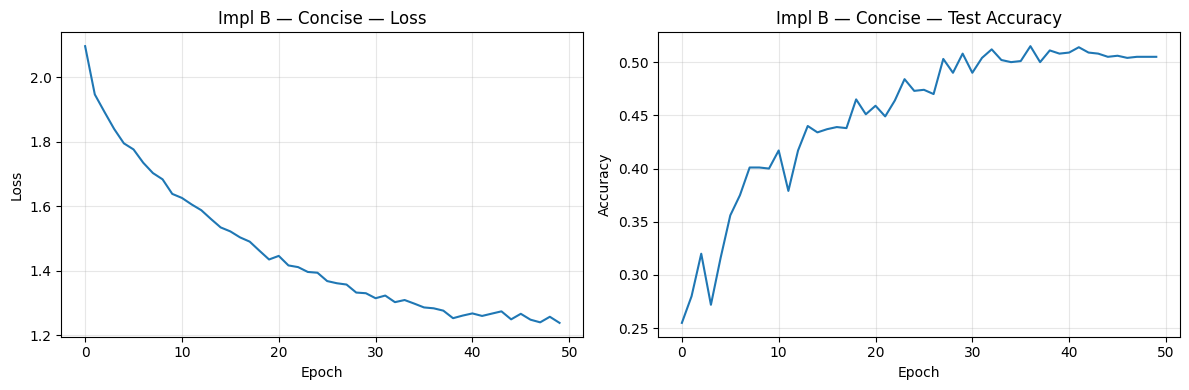

最终测试准确率: 0.5050


In [16]:
plot_results(losses_b, accs_b, title='Impl B — Concise')
print(f'最终测试准确率: {accs_b[-1]:.4f}')

---

## 5. 结果对比

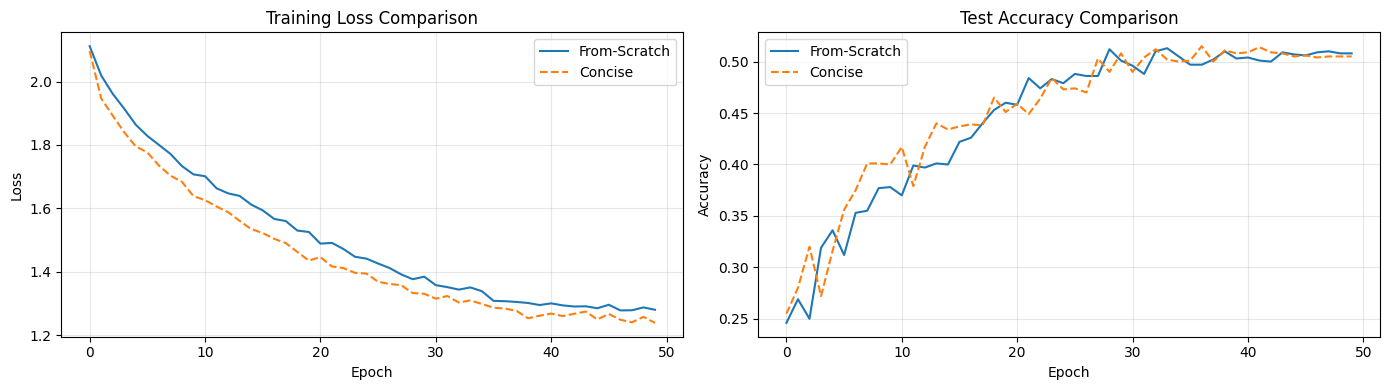

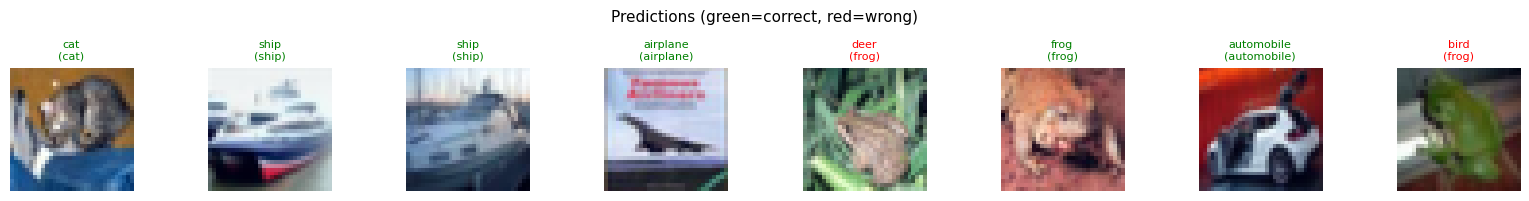

实现 A 最终准确率: 0.5080
实现 B 最终准确率: 0.5050
两种实现架构等价，结果差异仅来自随机初始化。


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# ── 损失曲线对比 ──
ax1.plot(losses_a, label='From-Scratch')
ax1.plot(losses_b, '--', label='Concise')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── 准确率对比 ──
ax2.plot(accs_a, label='From-Scratch')
ax2.plot(accs_b, '--', label='Concise')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Test Accuracy Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 预测样本展示 ──
model_a.eval()
test_imgs, test_labels = next(iter(test_loader))
with torch.no_grad():
    preds = model_a(test_imgs[:8].to(device)).argmax(1).cpu()

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = test_imgs[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    pred = CIFAR10_CLASSES[preds[i]]
    true = CIFAR10_CLASSES[test_labels[i]]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'{pred}\n({true})', fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('Predictions (green=correct, red=wrong)', fontsize=11)
plt.tight_layout()
plt.show()

print(f'实现 A 最终准确率: {accs_a[-1]:.4f}')
print(f'实现 B 最终准确率: {accs_b[-1]:.4f}')
print('两种实现架构等价，结果差异仅来自随机初始化。')

---

## 附录 A：预训练模型微调

ViT 的核心优势之一是**预训练-微调**范式。使用在 ImageNet 上预训练的 ViT-B/16（86M 参数），
冻结主干网络，仅替换并训练分类头，即可快速适配下游任务。

微调流程：
1. 加载 `torchvision.models.vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)`
2. 冻结所有参数：`param.requires_grad = False`
3. 替换分类头：`model.heads = nn.Linear(768, num_classes)`
4. 仅训练分类头（7,690 参数 vs 86M 总参数）

> 注意：ViT-B/16 期望 $224 \times 224$ 输入，需要对 CIFAR-10 图像上采样。
> 此部分需下载预训练权重（~330MB），在无网络环境下会自动跳过。

In [18]:
try:
    from torchvision.models import vit_b_16, ViT_B_16_Weights

    # 加载 ImageNet 预训练 ViT-B/16
    weights = ViT_B_16_Weights.IMAGENET1K_V1
    pretrained_model = vit_b_16(weights=weights).to(device)

    # 冻结主干
    for param in pretrained_model.parameters():
        param.requires_grad = False

    # 替换分类头（仅此部分可训练）
    pretrained_model.heads = nn.Sequential(
        nn.Linear(768, NUM_CLASSES)
    ).to(device)

    trainable = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
    total_p = sum(p.numel() for p in pretrained_model.parameters())
    print(f'Total: {total_p:,}  Trainable: {trainable:,}  ({trainable/total_p*100:.2f}%)')

    # 微调数据（CIFAR-10 上采样到 224×224）
    ft_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])
    ft_train = datasets.CIFAR10(root='./data', train=True, transform=ft_transform)
    ft_train = Subset(ft_train, range(200))
    ft_loader = DataLoader(ft_train, batch_size=16, shuffle=True)

    ft_test = datasets.CIFAR10(root='./data', train=False, transform=ft_transform)
    ft_test = Subset(ft_test, range(100))
    ft_test_loader = DataLoader(ft_test, batch_size=16, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(pretrained_model.heads.parameters(), lr=1e-3)

    for epoch in range(3):
        pretrained_model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in ft_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = pretrained_model(imgs)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
        print(f'Epoch {epoch+1}/3  Loss: {total_loss/len(ft_loader):.4f}  Acc: {correct/total:.4f}')

    # 测试
    pretrained_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in ft_test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (pretrained_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    print(f'\n预训练微调测试准确率: {correct/total:.4f}')
    print(f'仅训练 {trainable:,} 个参数即可获得良好效果，体现预训练的价值。')

except Exception as e:
    print(f'预训练微调跳过: {e}')
    print('需要网络连接下载预训练权重。可在 Colab 中运行此部分。')

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 69.9MB/s]


Total: 85,806,346  Trainable: 7,690  (0.01%)
Epoch 1/3  Loss: 1.8885  Acc: 0.4200
Epoch 2/3  Loss: 0.9351  Acc: 0.8800
Epoch 3/3  Loss: 0.5106  Acc: 0.9400

预训练微调测试准确率: 0.8700
仅训练 7,690 个参数即可获得良好效果，体现预训练的价值。


---

## 附录 B：可视化分析

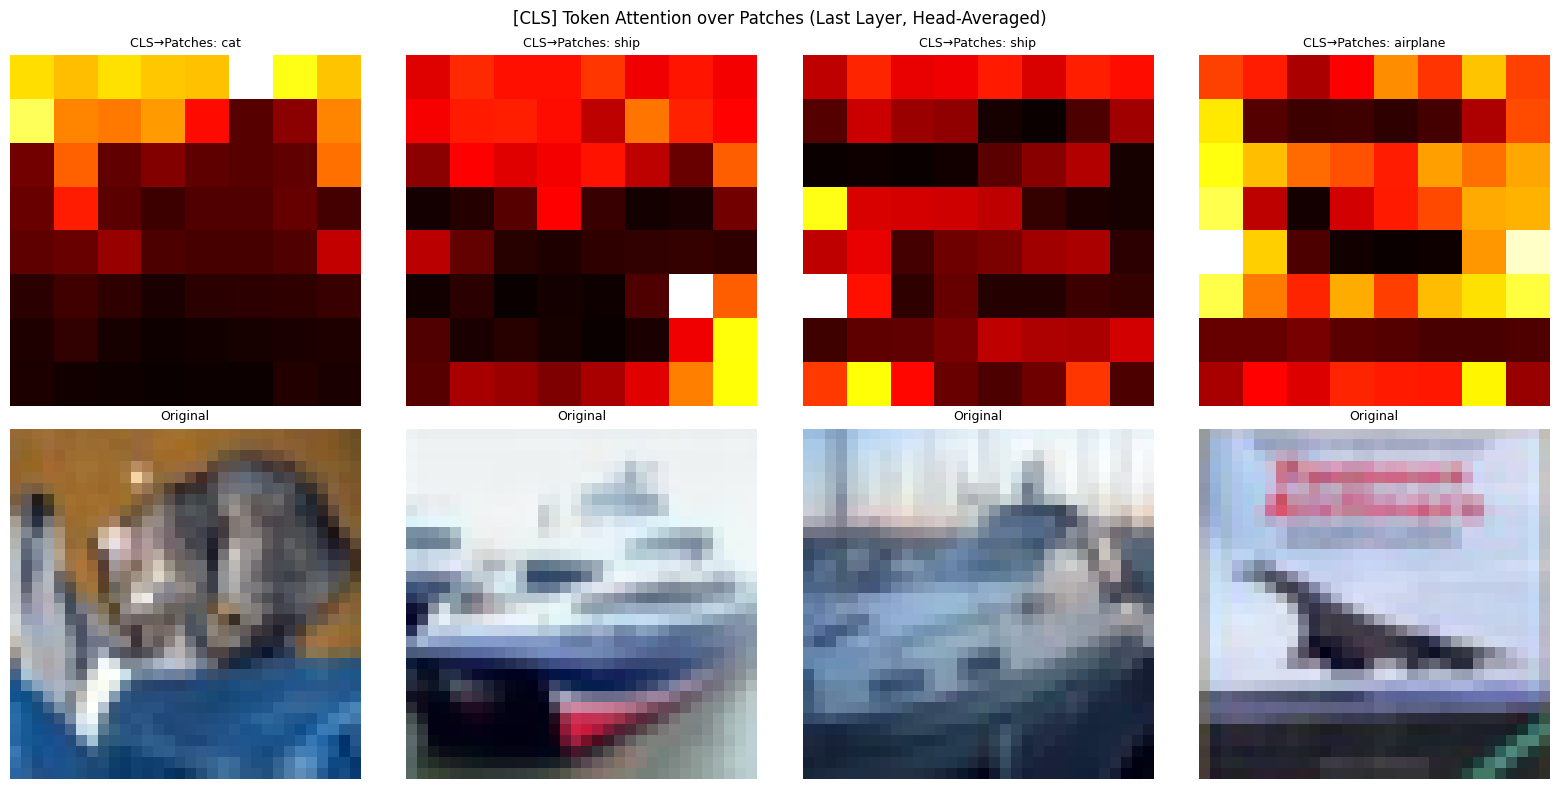

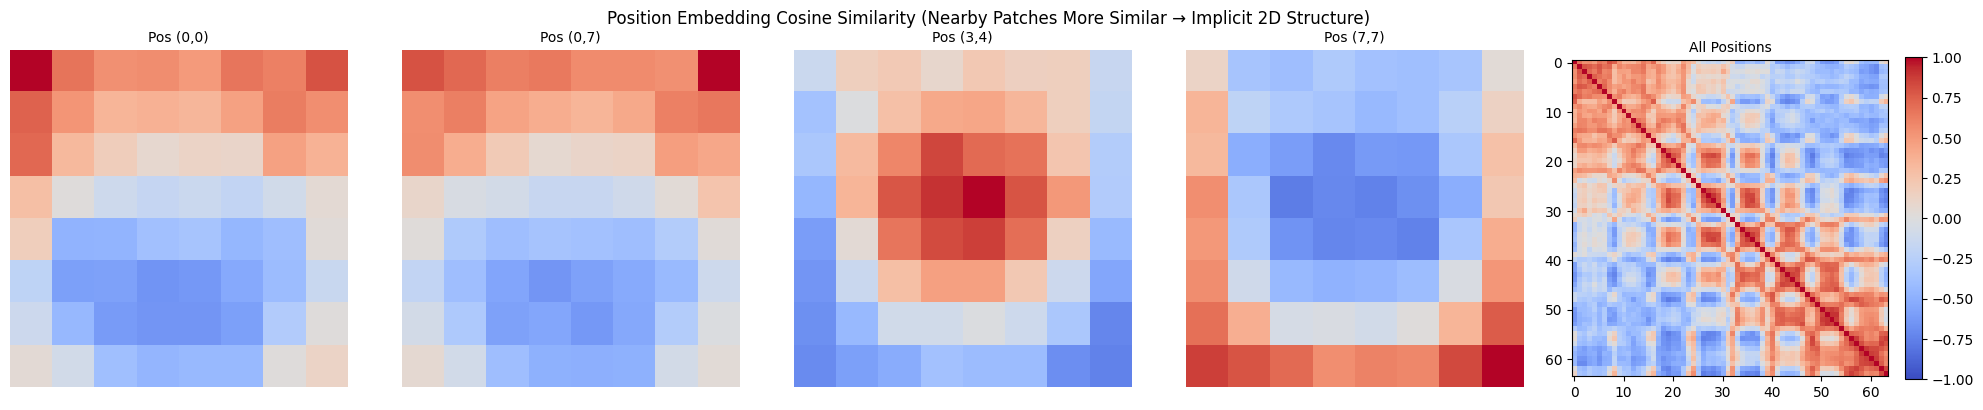

In [19]:
# ── [CLS] Token 注意力分布 ──
model_a.eval()
viz_imgs, viz_labels = next(iter(test_loader))
viz_imgs_dev = viz_imgs[:4].to(device)
with torch.no_grad():
    _ = model_a(viz_imgs_dev)

# 取最后一个 Transformer Block 的注意力权重
attn_weights = model_a.blocks[-1].attn._attn_weights  # (4, heads, 65, 65)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # 上排: CLS 对各 Patch 的注意力（多头平均）
    cls_attn = attn_weights[i].mean(dim=0)[0, 1:].cpu().numpy()  # (64,)
    cls_attn = cls_attn.reshape(8, 8)  # 8×8 Patch 网格
    axes[0, i].imshow(cls_attn, cmap='hot')
    axes[0, i].set_title(f'CLS→Patches: {CIFAR10_CLASSES[viz_labels[i]]}', fontsize=9)
    axes[0, i].axis('off')

    # 下排: 对应原图
    img = viz_imgs[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[1, i].imshow(img)
    axes[1, i].set_title('Original', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('[CLS] Token Attention over Patches (Last Layer, Head-Averaged)', fontsize=12)
plt.tight_layout()
plt.show()

# ── 位置编码余弦相似度 ──
pos = model_a.pos_embed[0, 1:].detach().cpu()  # (64, D)，排除 CLS
cos_sim = torch.nn.functional.cosine_similarity(
    pos.unsqueeze(0), pos.unsqueeze(1), dim=-1
)  # (64, 64)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
refs = [0, 7, 28, 63]  # 4 个参考位置
for i, ref in enumerate(refs):
    sim = cos_sim[ref].reshape(8, 8).numpy()
    axes[i].imshow(sim, cmap='coolwarm', vmin=-1, vmax=1)
    row, col = ref // 8, ref % 8
    axes[i].set_title(f'Pos ({row},{col})', fontsize=10)
    axes[i].axis('off')

im = axes[4].imshow(cos_sim.numpy(), cmap='coolwarm', vmin=-1, vmax=1)
axes[4].set_title('All Positions', fontsize=10)
plt.colorbar(im, ax=axes[4], fraction=0.046)

plt.suptitle('Position Embedding Cosine Similarity (Nearby Patches More Similar → Implicit 2D Structure)', fontsize=12)
plt.tight_layout()
plt.show()

---

## 附录 C：面试拓展

### 高频面试题

**Q1: ViT 的核心思想是什么？与 CNN 的根本区别？**

ViT 将图像切分为 Patch 序列，用标准 Transformer Encoder 进行建模：
- CNN 通过卷积核逐层提取局部特征，具有强归纳偏置（局部性、平移等变性）
- ViT 通过自注意力直接建模全局关系，几乎不引入视觉先验
- 代价：ViT 需要大规模数据（14M+）才能超越 CNN；在小数据集上表现不如 CNN

**Q2: 为什么用 Patch 而不是像素作为 Token？**

- 自注意力计算复杂度为 $O(N^2)$，$N$ 为序列长度
- 若以像素为 Token：$224 \times 224 = 50176$，注意力矩阵 $50176^2 \approx 25$ 亿，不可行
- 以 $16 \times 16$ Patch 为 Token：$14 \times 14 = 196$，注意力矩阵仅 $196^2 \approx 38000$，完全可行
- Patch 大小是计算效率和细粒度之间的权衡

**Q3: ViT 的位置编码为什么用可学习的 1D 编码而非固定 2D 编码？**

- 论文消融实验表明 1D、2D、相对位置编码效果接近
- 1D 编码已能隐式学到 2D 空间结构（相邻 Patch 的编码更相似）
- 可学习编码比固定编码（如正弦余弦）有更大的灵活性
- 简单性原则：1D 编码实现最简单，效果不输复杂方案

**Q4: [CLS] Token 的作用是什么？能否用全局平均池化替代？**

- [CLS] Token 借鉴 BERT，作为全局聚合器，通过自注意力收集所有 Patch 的信息
- 可以用全局平均池化（GAP）替代，对所有 Patch 输出取平均
- 实际性能：两者效果相当，DeiT 等后续工作倾向使用 GAP
- [CLS] 的优势：概念清晰，不改变 Patch 位置编码的设计

**Q5: ViT 微调时如何处理不同分辨率？**

- Patch 大小保持不变，更高分辨率 → 更多 Patch → 更长序列
- Transformer 可处理任意长度序列，但预训练的位置编码维度固定
- 解决方案：对位置编码进行 2D 插值，根据 Patch 在图像中的空间位置插值
- 示例：$224 \times 224$（预训练）→ $384 \times 384$（微调），Patch 从 196 增到 576

**Q6: 什么是归纳偏置（Inductive Bias）？ViT 为什么需要更多数据？**

- 归纳偏置：模型架构中内置的关于数据结构的先验假设
- CNN 的归纳偏置：局部性（卷积核）、平移等变性（共享权重）、层次结构（逐层扩大感受野）
- ViT 的归纳偏置极少：仅在 Patch 切分时利用了 2D 结构，自注意力是全局操作
- 因此 ViT 需要大规模数据来**从数据中学习**这些视觉规律，而 CNN 已将其编码在架构中

**Q7: ViT 的计算复杂度分析？**

| 组件 | 复杂度 |
|------|--------|
| 自注意力 | $O(N^2 \cdot D)$，$N$ 为 Patch 数 |
| MLP | $O(N \cdot D \cdot D_{ff})$ |
| Patch Embedding | $O(N \cdot P^2 C \cdot D)$ |

- Patch 越小 → $N$ 越大 → 自注意力开销越高（二次增长）
- CNN 的卷积复杂度与图像大小线性相关（局部操作）
- ViT 的优势：在相同性能下，训练计算量可能更少（Transformer 高度并行化）

**Q8: ViT vs CNN vs Hybrid？如何选择？**

| 对比维度 | CNN | ViT | Hybrid |
|---------|-----|-----|--------|
| 数据需求 | 少（强归纳偏置） | 多（弱归纳偏置） | 中等 |
| 小数据表现 | 好 | 差 | 较好 |
| 大数据表现 | 有上限 | 持续提升 | 较好 |
| 全局建模 | 需深层网络 | 第一层即全局 | 混合 |
| 计算效率 | 高（局部操作） | 中（$O(N^2)$） | 中 |
| 代表模型 | ResNet, EfficientNet | ViT, DeiT | CoAtNet, ViTAE |

### 进阶探索方向

- **DeiT**: 引入知识蒸馏和数据增强策略，使 ViT 在 ImageNet 单数据集上也能训练良好
- **Swin Transformer**: 引入滑动窗口注意力和层次结构，降低计算复杂度，适用于密集预测任务
- **MAE (Masked Autoencoder)**: 将 BERT 的 MLM 思想引入视觉，通过遮盖 Patch 进行自监督预训练
- **DINO / DINOv2**: 自监督 ViT 训练，无需标签即可学到强大的视觉特征
- **FlashAttention**: 优化注意力计算的显存和速度，使 ViT 能处理更长序列